# 主策略优化研究：二阶段信号过滤实验

本 notebook 参考 `回测demo.ipynb` 的主策略交割结果，做一个不改动原策略 notebook、不改动 API/回测函数的优化研究。

核心思路：主策略已经完成信号生成与分钟线交易回测，这里先基于最新交割明细做“二阶段过滤”实验，寻找哪些开盘前可用的特征能提升收益/回撤比。这样可以快速筛掉明显无效方向，再决定是否值得把规则回写到正式信号生成逻辑中。

注意：实验会同时展示一些诊断上很强、但实盘不可用的事后字段，并在最终候选中剔除，避免未来函数。

In [1]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

# 使用主策略当前最新的完整交割明细 CSV。
# 这份文件来自 `回测demo.ipynb` 的主策略信号与 cal_trade_info 回测结果，
# 不在本 notebook 中重新跑分钟线交易函数，避免重复消耗大量时间。
SIGNAL_FILE = Path("信号文件") / "断板低开-5--2.5 20260509_120028(sma7).csv"
assert SIGNAL_FILE.exists(), f"找不到主策略交割明细: {SIGNAL_FILE}"

raw_df = pd.read_csv(SIGNAL_FILE, encoding="utf-8-sig")
raw_df.shape, raw_df.head(3)

((2360, 49),
           code  name trading_date   open   high    low  close  pre_close       volume        amount  limit_up  limit_down  is_st  is_suspended  adj_factor  turnover_rate  \
 0  SHSE.601113  华鼎股份   2024-01-25   3.93   3.98   3.65   3.92       4.06  151313449.0  5.815766e+08      4.47        3.65  False         False    2.116620        13.7040   
 1  SHSE.605255  天普股份   2024-01-25  19.20  19.68  18.63  19.68      19.75   11394529.0  2.201117e+08     21.73       17.78  False         False    1.092178         8.4983   
 2  SHSE.603083  剑桥科技   2024-01-26  43.00  47.34  42.41  43.52      45.02   72132507.0  3.247274e+09     49.52       40.52  False         False    2.224904        27.5196   
 
      total_mv  mv_A_free_float  is_limit_up  is_broken_limit  is_db limit_status_ext limit_status limit_desc last_limit_desc  avg_limit_turnover_5   sma_5      sma_7  open_pct  \
 0   43.282767        43.282767        False            False  False              NaN          未涨停        未涨停

In [2]:
def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    """清洗主策略交割明细，并补充优化实验需要的派生特征。"""
    out = df.copy()
    out["trading_date"] = pd.to_datetime(out["trading_date"])
    out["buy_time"] = pd.to_datetime(out["buy_time"])
    out["sell_time"] = pd.to_datetime(out["sell_time"])
    out["profit"] = pd.to_numeric(out["profit"], errors="coerce")
    out = out.dropna(subset=["profit", "buy_time"]).copy()

    # 沿用主 notebook 中固定 0.4 仓位的理论等权口径。
    out["weight_profit"] = out["profit"] * 0.4

    # cal_n_lowest 默认不含当日，所以这里的开盘价 / 前 30 日低点在开盘前可用于判断。
    out["price_lowest_30"] = out["open"] / out["lowest_30"]

    # 将 “N天M板” 拆成数值，便于做区间搜索；无法解析的描述保留为 NaN。
    desc_num = out["last_limit_desc"].astype(str).str.extract(r"(\d+)天(\d+)板")
    out["limit_days"] = pd.to_numeric(desc_num[0], errors="coerce")
    out["limit_boards"] = pd.to_numeric(desc_num[1], errors="coerce")
    return out


df = prepare_df(raw_df)
print(f"样本数: {len(df):,}")
print(f"回测区间: {df['buy_time'].min()} ~ {df['buy_time'].max()}")
df[["trading_date", "code", "name", "open_pct", "mv_A_free_float", "pre_close_sma7_pct", "last_limit_desc", "prev_limit_status", "profit"]].head()

样本数: 2,360
回测区间: 2024-01-05 09:30:00 ~ 2026-05-08 09:30:00


,trading_date,code,name,open_pct,mv_A_free_float,pre_close_sma7_pct,last_limit_desc,prev_limit_status,profit
0,2024-01-25,SHSE.601113,华鼎股份,-3.201970,43.282767,6.362275,2天2板,断板,3.999270
1,2024-01-25,SHSE.605255,天普股份,-2.784810,26.386944,4.119596,2天1板,断板,-0.435134
2,2024-01-26,SHSE.603083,剑桥科技,-4.486895,114.071874,16.146390,5天4板,断板,-9.471324
3,2024-01-26,SHSE.603600,永艺股份,-3.846154,36.785537,7.286017,4天2板,断板,-6.828367
4,2024-01-26,SZSE.002731,ST萃华,-4.488595,28.236406,5.220661,7天3板,断板,-10.350278


In [3]:
def calc_metrics(data: pd.DataFrame, profit_col: str = "weight_profit", start=None, end=None) -> dict:
    """复刻主 notebook report_backtest_full 的核心净值口径。"""
    x = data.copy()
    if start is not None:
        x = x[x["buy_time"] >= pd.to_datetime(start)]
    if end is not None:
        x = x[x["buy_time"] <= pd.to_datetime(end)]
    x = x.dropna(subset=[profit_col, "buy_time"])
    if x.empty:
        return {"样本数": 0, "最终净值": np.nan, "总收益率": np.nan, "年化收益率": np.nan, "最大回撤": np.nan, "夏普": np.nan, "胜率": np.nan, "盈亏比": np.nan, "日均买入数": np.nan, "单笔均值": np.nan}

    # 每个买入日先对当日所有股票收益取平均，再进行复利累计。
    daily_returns = x.groupby(x["buy_time"].dt.date)[profit_col].mean() / 100
    curve = (1 + daily_returns).cumprod()
    total_return = curve.iloc[-1] - 1
    days = (pd.to_datetime(curve.index[-1]) - pd.to_datetime(curve.index[0])).days
    years = days / 365 if days > 0 else np.nan
    annual_return = curve.iloc[-1] ** (1 / years) - 1 if years and years > 0 and curve.iloc[-1] > 0 else np.nan
    max_drawdown = (curve / curve.cummax() - 1).min()
    daily_net_ret = curve.pct_change().dropna()
    sharpe = daily_net_ret.mean() / daily_net_ret.std() * np.sqrt(252) if len(daily_net_ret) > 1 and daily_net_ret.std() > 0 else np.nan

    non_zero = x[x[profit_col] != 0]
    win_rate = (non_zero[profit_col] > 0).mean() if len(non_zero) else np.nan
    avg_win = x.loc[x[profit_col] > 0, profit_col].mean()
    avg_loss = abs(x.loc[x[profit_col] < 0, profit_col].mean())
    profit_loss_ratio = avg_win / avg_loss if avg_loss and not np.isnan(avg_loss) else np.nan
    avg_daily_buy = x.groupby(x["buy_time"].dt.date)["code"].nunique().mean()

    return {"样本数": len(x), "最终净值": curve.iloc[-1], "总收益率": total_return, "年化收益率": annual_return, "最大回撤": max_drawdown, "夏普": sharpe, "胜率": win_rate, "盈亏比": profit_loss_ratio, "日均买入数": avg_daily_buy, "单笔均值": x[profit_col].mean()}


def equity_curve(data: pd.DataFrame, profit_col: str = "weight_profit") -> pd.Series:
    daily_returns = data.dropna(subset=[profit_col, "buy_time"]).groupby(data["buy_time"].dt.date)[profit_col].mean() / 100
    return (1 + daily_returns).cumprod()


def format_metrics_table(rows: list[dict]) -> pd.DataFrame:
    table = pd.DataFrame(rows)
    for col in ["总收益率", "年化收益率", "最大回撤", "胜率"]:
        if col in table:
            table[col] = table[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "")
    for col in ["最终净值", "夏普", "盈亏比", "日均买入数", "单笔均值"]:
        if col in table:
            table[col] = table[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")
    return table


baseline_rows = []
for name, kwargs in [("全区间", {}), ("训练期(2024-2025)", {"end": "2025-12-31"}), ("样本外(2026)", {"start": "2026-01-01"})]:
    baseline_rows.append({"区间": name, **calc_metrics(df, **kwargs)})
format_metrics_table(baseline_rows)

,区间,样本数,最终净值,总收益率,年化收益率,最大回撤,夏普,胜率,盈亏比,日均买入数,单笔均值
0,全区间,2360,2.6579,165.79%,51.86%,-32.26%,1.3450,43.56%,1.4155,4.5385,0.1209
1,训练期(2024-2025),2035,2.3485,134.85%,53.70%,-32.26%,1.3815,42.60%,1.4414,4.6145,0.0925
2,样本外(2026),320,1.1098,10.98%,36.24%,-19.42%,0.9139,49.06%,1.2673,4.1026,0.2729


## 候选方向设计

我把优化方向分成两类：

1. **可交易候选**：开盘买入前可获得或可近似锁定的信息，包括低开幅度、自由流通市值、昨日乖离率、前 5 日涨停平均换手、前一日涨跌幅、前一日涨停结构、开盘价相对前 30 日低点等。
2. **诊断但剔除候选**：当日换手率、卖出原因等，它们可能解释收益，但开盘买入时不可得，不能作为实盘过滤条件。

最终评分使用训练期和 2026 样本外共同约束，不只按全区间收益排序，避免单纯追历史最优。

In [4]:
def make_interval_filters(data: pd.DataFrame, col: str, q_points=(0, 0.2, 0.4, 0.6, 0.8, 1), min_count=160):
    """按分位点生成区间候选，保持候选数量可控，避免过度细分。"""
    filters = []
    s = data[col].replace([np.inf, -np.inf], np.nan).dropna()
    if s.nunique() < 4:
        return filters
    qs = sorted(set(np.nanquantile(s, q_points).round(6)))
    for lo, hi in itertools.combinations(qs, 2):
        cond = (data[col] >= lo) & (data[col] <= hi)
        if int(cond.sum()) >= min_count:
            filters.append((f"{col} in [{lo:.4g}, {hi:.4g}]", cond))
    return filters


def score_rule(data: pd.DataFrame, rule_name: str, cond: pd.Series) -> dict:
    """综合评分：偏向样本外表现，同时要求训练期不能太差，并把回撤纳入惩罚。"""
    sub = data[cond]
    all_m = calc_metrics(sub)
    train_m = calc_metrics(sub, end="2025-12-31")
    test_m = calc_metrics(sub, start="2026-01-01")
    score = ((test_m["年化收益率"] if pd.notna(test_m["年化收益率"]) else -9) + 0.4 * (train_m["年化收益率"] if pd.notna(train_m["年化收益率"]) else -9) + 0.2 * (all_m["夏普"] if pd.notna(all_m["夏普"]) else 0) + 0.5 * (test_m["最大回撤"] if pd.notna(test_m["最大回撤"]) else -1))
    return {"规则": rule_name, "样本数": len(sub), "全区间_最终净值": all_m["最终净值"], "全区间_年化": all_m["年化收益率"], "全区间_最大回撤": all_m["最大回撤"], "全区间_夏普": all_m["夏普"], "全区间_胜率": all_m["胜率"], "全区间_盈亏比": all_m["盈亏比"], "训练期_样本数": train_m["样本数"], "训练期_年化": train_m["年化收益率"], "训练期_最大回撤": train_m["最大回撤"], "训练期_夏普": train_m["夏普"], "样本外_样本数": test_m["样本数"], "样本外_年化": test_m["年化收益率"], "样本外_最大回撤": test_m["最大回撤"], "样本外_夏普": test_m["夏普"], "样本外_最终净值": test_m["最终净值"], "score": score}


tradable_num_cols = ["open_pct", "mv_A_free_float", "pre_close_sma7_pct", "avg_limit_turnover_5", "price_lowest_30", "pre_pct", "limit_days", "limit_boards"]
diagnostic_only_num_cols = ["turnover_rate"]

tradable_filters = []
for col in tradable_num_cols:
    tradable_filters.extend(make_interval_filters(df, col))

for col in ["prev_limit_status", "last_limit_desc"]:
    for val in sorted(df[col].dropna().unique()):
        cond = df[col].eq(val)
        if int(cond.sum()) >= 120:
            tradable_filters.append((f"{col} == {val}", cond))

single_rows = []
for name, cond in tradable_filters:
    result = score_rule(df, name, cond)
    if result["训练期_样本数"] >= 100 and result["样本外_样本数"] >= 20:
        single_rows.append(result)

single_result = pd.DataFrame(single_rows).sort_values(["score", "样本外_年化", "全区间_夏普"], ascending=False)
single_result.head(20)

,规则,样本数,全区间_最终净值,全区间_年化,全区间_最大回撤,全区间_夏普,全区间_胜率,全区间_盈亏比,训练期_样本数,训练期_年化,训练期_最大回撤,训练期_夏普,样本外_样本数,样本外_年化,样本外_最大回撤,样本外_夏普,样本外_最终净值,score
99,"limit_days in [5, 16]",572,3.205377,0.650009,-0.383958,1.557112,0.430070,1.578180,494,0.345036,-0.383958,1.080230,77,4.015252,-0.153275,3.685620,1.721825,4.388051
66,"price_lowest_30 in [1.288, 1.537]",944,2.801845,0.558900,-0.338434,1.569267,0.442797,1.456491,819,0.317180,-0.338434,1.076217,122,3.032376,-0.092158,4.807830,1.599800,3.427022
0,"open_pct in [-5, -4.306]",475,2.303120,0.432630,-0.264784,1.532697,0.454737,1.453429,413,0.225185,-0.264784,1.041243,62,2.699152,-0.155326,3.748895,1.542871,3.018102
2,"open_pct in [-5, -3.287]",1416,3.288650,0.668303,-0.307444,1.621667,0.438559,1.424679,1226,0.450554,-0.307444,1.238084,189,2.478132,-0.096497,3.674031,1.522041,2.934439
27,"mv_A_free_float in [76.14, 134]",472,4.279691,0.868337,-0.335947,2.701788,0.451271,1.524652,376,0.734934,-0.335947,2.566787,94,1.790416,-0.158666,2.987579,1.413137,2.545415
28,"mv_A_free_float in [76.14, 983.4]",944,6.006270,1.161404,-0.301531,2.669220,0.466102,1.474711,743,1.076660,-0.301531,2.704779,197,1.594057,-0.155846,2.292543,1.378813,2.480642
31,"pre_close_sma7_pct in [0.01286, 8.534]",944,1.672259,0.248368,-0.370125,0.981377,0.443856,1.454956,830,0.051310,-0.370125,0.398152,112,2.297515,-0.134161,4.421822,1.456345,2.447234
98,"limit_days in [4, 16]",980,1.653476,0.241347,-0.441205,0.813042,0.426531,1.429408,834,0.045504,-0.441205,0.398685,142,2.302894,-0.254758,2.514273,1.495755,2.356325
29,"mv_A_free_float in [134, 983.4]",472,2.654089,0.536104,-0.314881,2.455824,0.480932,1.428698,367,0.372715,-0.314881,2.158898,103,1.653296,-0.159805,2.955671,1.389345,2.213645
58,"avg_limit_turnover_5 in [11.76, 51.68]",944,3.156793,0.659886,-0.251037,1.648691,0.473517,1.394770,810,0.539840,-0.251037,1.456770,131,1.664037,-0.164015,2.572904,1.314977,2.127704


In [5]:
filter_map = dict(tradable_filters)
top_single_rules = single_result.head(35)["规则"].tolist()
combo_rows = []

for i, rule_a in enumerate(top_single_rules):
    for rule_b in top_single_rules[i + 1:]:
        col_a = rule_a.split(" in ")[0].split(" == ")[0]
        col_b = rule_b.split(" in ")[0].split(" == ")[0]
        if col_a == col_b:
            continue
        cond = filter_map[rule_a] & filter_map[rule_b]
        if int(cond.sum()) < 120:
            continue
        result = score_rule(df, f"{rule_a} AND {rule_b}", cond)
        if result["训练期_样本数"] >= 80 and result["样本外_样本数"] >= 20:
            combo_rows.append(result)

combo_result = pd.DataFrame(combo_rows).sort_values(["score", "样本外_年化", "全区间_夏普"], ascending=False)
combo_result.head(20)

,规则,样本数,全区间_最终净值,全区间_年化,全区间_最大回撤,全区间_夏普,全区间_胜率,全区间_盈亏比,训练期_样本数,训练期_年化,训练期_最大回撤,训练期_夏普,样本外_样本数,样本外_年化,样本外_最大回撤,样本外_夏普,样本外_最终净值,score
0,"limit_days in [5, 16] AND open_pct in [-5, -3....",358,2.514803,0.510591,-0.293420,1.792272,0.435754,1.618514,313,0.076124,-0.293420,0.661794,44,14.451573,-0.069452,7.084440,2.101302,14.805751
9,"limit_days in [5, 16] AND open_pct in [-5, -3....",244,2.823918,0.597397,-0.262360,2.358261,0.438525,1.683592,211,0.175147,-0.262360,1.211671,33,13.581420,-0.082405,6.870169,2.068525,14.081928
3,"limit_days in [5, 16] AND pre_close_sma7_pct i...",255,2.710396,0.554477,-0.327110,2.411580,0.470588,1.553788,224,0.206474,-0.327110,1.293572,31,9.325687,-0.081948,6.488274,1.871674,9.849618
17,"limit_days in [5, 16] AND avg_limit_turnover_5...",516,4.108377,0.864313,-0.398766,1.865450,0.441860,1.656118,444,0.450105,-0.398766,1.292876,71,8.991134,-0.153275,4.632152,1.902586,9.467628
68,"open_pct in [-5, -3.287] AND mv_A_free_float i...",554,7.284141,1.348289,-0.195737,3.223379,0.478339,1.588224,435,0.848035,-0.195737,2.848201,118,7.923429,-0.124803,4.167585,2.090818,8.844917
12,"limit_days in [5, 16] AND open_pct in [-4.306,...",228,0.732717,-0.130463,-0.611823,-0.230357,0.412281,1.425068,200,-0.363171,-0.611823,-1.847281,27,6.869751,-0.064185,6.853200,1.701142,6.646319
19,"limit_days in [5, 16] AND prev_limit_status == 断板",435,2.952918,0.608972,-0.396201,1.723462,0.450575,1.528024,372,0.281142,-0.396201,1.039003,62,5.831387,-0.117908,4.312692,1.747232,6.229582
6,"limit_days in [5, 16] AND avg_limit_turnover_5...",433,2.298765,0.443293,-0.469929,1.457800,0.436490,1.563911,370,0.138085,-0.469929,0.747121,62,5.918063,-0.154274,4.605184,1.716862,6.187720
2,"limit_days in [5, 16] AND mv_A_free_float in [...",264,2.752436,0.546994,-0.385184,2.172179,0.454545,1.568139,220,0.188827,-0.385184,1.072813,43,5.592120,-0.089352,4.640034,1.887992,6.057411
85,"open_pct in [-5, -3.287] AND avg_limit_turnove...",1127,3.527432,0.729354,-0.274655,1.786737,0.454303,1.421545,979,0.382372,-0.274655,1.160829,147,5.510366,-0.090186,5.448098,1.795198,5.975569


In [6]:
search_result = pd.concat([single_result.assign(类型="单因子"), combo_result.assign(类型="二因子组合")], ignore_index=True).sort_values(["score", "样本外_年化", "全区间_夏普"], ascending=False)

# 最终规则选择标准：开盘前可用、全区间优于基线、训练期与 2026 样本外都不弱、样本数不能太小。
BEST_RULE = "open_pct in [-5, -3.287] AND mv_A_free_float in [76.14, 983.4]"
best_cond = filter_map["open_pct in [-5, -3.287]"] & filter_map["mv_A_free_float in [76.14, 983.4]"]
best_df = df[best_cond].copy()
search_result.head(30)

,规则,样本数,全区间_最终净值,全区间_年化,全区间_最大回撤,全区间_夏普,全区间_胜率,全区间_盈亏比,训练期_样本数,训练期_年化,训练期_最大回撤,训练期_夏普,样本外_样本数,样本外_年化,样本外_最大回撤,样本外_夏普,样本外_最终净值,score,类型
116,"limit_days in [5, 16] AND open_pct in [-5, -3....",358,2.514803,0.510591,-0.293420,1.792272,0.435754,1.618514,313,0.076124,-0.293420,0.661794,44,14.451573,-0.069452,7.084440,2.101302,14.805751,二因子组合
117,"limit_days in [5, 16] AND open_pct in [-5, -3....",244,2.823918,0.597397,-0.262360,2.358261,0.438525,1.683592,211,0.175147,-0.262360,1.211671,33,13.581420,-0.082405,6.870169,2.068525,14.081928,二因子组合
118,"limit_days in [5, 16] AND pre_close_sma7_pct i...",255,2.710396,0.554477,-0.327110,2.411580,0.470588,1.553788,224,0.206474,-0.327110,1.293572,31,9.325687,-0.081948,6.488274,1.871674,9.849618,二因子组合
119,"limit_days in [5, 16] AND avg_limit_turnover_5...",516,4.108377,0.864313,-0.398766,1.865450,0.441860,1.656118,444,0.450105,-0.398766,1.292876,71,8.991134,-0.153275,4.632152,1.902586,9.467628,二因子组合
120,"open_pct in [-5, -3.287] AND mv_A_free_float i...",554,7.284141,1.348289,-0.195737,3.223379,0.478339,1.588224,435,0.848035,-0.195737,2.848201,118,7.923429,-0.124803,4.167585,2.090818,8.844917,二因子组合
121,"limit_days in [5, 16] AND open_pct in [-4.306,...",228,0.732717,-0.130463,-0.611823,-0.230357,0.412281,1.425068,200,-0.363171,-0.611823,-1.847281,27,6.869751,-0.064185,6.853200,1.701142,6.646319,二因子组合
122,"limit_days in [5, 16] AND prev_limit_status == 断板",435,2.952918,0.608972,-0.396201,1.723462,0.450575,1.528024,372,0.281142,-0.396201,1.039003,62,5.831387,-0.117908,4.312692,1.747232,6.229582,二因子组合
123,"limit_days in [5, 16] AND avg_limit_turnover_5...",433,2.298765,0.443293,-0.469929,1.457800,0.436490,1.563911,370,0.138085,-0.469929,0.747121,62,5.918063,-0.154274,4.605184,1.716862,6.187720,二因子组合
124,"limit_days in [5, 16] AND mv_A_free_float in [...",264,2.752436,0.546994,-0.385184,2.172179,0.454545,1.568139,220,0.188827,-0.385184,1.072813,43,5.592120,-0.089352,4.640034,1.887992,6.057411,二因子组合
125,"open_pct in [-5, -3.287] AND avg_limit_turnove...",1127,3.527432,0.729354,-0.274655,1.786737,0.454303,1.421545,979,0.382372,-0.274655,1.160829,147,5.510366,-0.090186,5.448098,1.795198,5.975569,二因子组合


In [7]:
comparison = []
for label, data in [("基线", df), ("优化过滤", best_df)]:
    for period, kwargs in [("全区间", {}), ("训练期(2024-2025)", {"end": "2025-12-31"}), ("样本外(2026)", {"start": "2026-01-01"})]:
        comparison.append({"策略": label, "区间": period, **calc_metrics(data, **kwargs)})

format_metrics_table(comparison)

,策略,区间,样本数,最终净值,总收益率,年化收益率,最大回撤,夏普,胜率,盈亏比,日均买入数,单笔均值
0,基线,全区间,2360,2.6579,165.79%,51.86%,-32.26%,1.3450,43.56%,1.4155,4.5385,0.1209
1,基线,训练期(2024-2025),2035,2.3485,134.85%,53.70%,-32.26%,1.3815,42.60%,1.4414,4.6145,0.0925
2,基线,样本外(2026),320,1.1098,10.98%,36.24%,-19.42%,0.9139,49.06%,1.2673,4.1026,0.2729
3,优化过滤,全区间,554,7.2841,628.41%,134.83%,-19.57%,3.2234,47.83%,1.5882,2.0219,0.5417
4,优化过滤,训练期(2024-2025),435,3.3583,235.83%,84.80%,-19.57%,2.8482,46.90%,1.5943,2.0139,0.4856
5,优化过滤,样本外(2026),118,2.0908,109.08%,792.34%,-12.48%,4.1676,50.85%,1.5552,2.0702,0.7212


C:\Users\20561\AppData\Local\Temp\ipykernel_62652\3788475685.py:12: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20561\AppData\Local\Temp\ipykernel_62652\3788475685.py:12: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20561\AppData\Local\Temp\ipykernel_62652\3788475685.py:12: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20561\AppData\Local\Temp\ipykernel_62652\3788475685.py:12: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20561\AppData\Local\Temp\ipykernel_62652\3788475685.py:12: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\20561\AppData\Local\Temp\ipykernel_62652\3788475685.py:12: UserWarning: Glyph 31574 (\

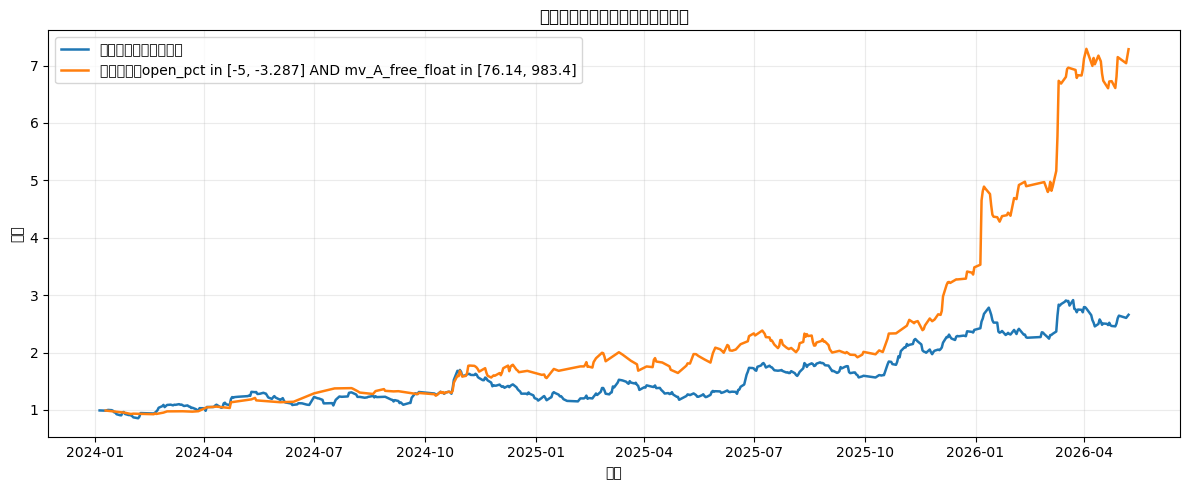

In [8]:
base_curve = equity_curve(df)
best_curve = equity_curve(best_df)

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(base_curve.index), base_curve.values, label="基线：主策略全部信号", linewidth=1.8)
plt.plot(pd.to_datetime(best_curve.index), best_curve.values, label=f"优化过滤：{BEST_RULE}", linewidth=1.8)
plt.title("主策略二阶段过滤：净值曲线对比")
plt.xlabel("日期")
plt.ylabel("净值")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# 诊断：展示“看起来很强但不能用于开盘实盘过滤”的字段，防止误用未来信息。
diagnostic_filters = []
for col in diagnostic_only_num_cols:
    diagnostic_filters.extend(make_interval_filters(df, col))
for col in ["sell_reason"]:
    for val in sorted(df[col].dropna().unique()):
        cond = df[col].eq(val)
        if int(cond.sum()) >= 120:
            diagnostic_filters.append((f"{col} == {val}", cond))

diagnostic_rows = []
for name, cond in diagnostic_filters:
    result = score_rule(df, name, cond)
    if result["训练期_样本数"] >= 100 and result["样本外_样本数"] >= 20:
        diagnostic_rows.append(result)

diagnostic_result = pd.DataFrame(diagnostic_rows).sort_values(["score", "样本外_年化", "全区间_夏普"], ascending=False)
diagnostic_result.head(10)

,规则,样本数,全区间_最终净值,全区间_年化,全区间_最大回撤,全区间_夏普,全区间_胜率,全区间_盈亏比,训练期_样本数,训练期_年化,训练期_最大回撤,训练期_夏普,样本外_样本数,样本外_年化,样本外_最大回撤,样本外_夏普,样本外_最终净值,score
15,sell_reason == 未涨停卖出,2093,44.043893,4.109802,-0.129562,4.917034,0.483516,1.889509,1812,3.712620,-0.129562,4.610341,276,7.452726,-0.037809,6.698705,2.029111,9.902276
14,"turnover_rate in [22.44, 55.09]",472,10.870704,1.888679,-0.236210,3.808594,0.559322,1.490834,401,1.632922,-0.236210,3.586278,68,4.682531,-0.132260,4.628511,1.571765,6.031289
13,"turnover_rate in [15.85, 55.09]",944,4.109289,0.870143,-0.279360,1.985836,0.492585,1.484222,813,0.803875,-0.279360,1.931758,127,1.418050,-0.208934,2.113955,1.267529,2.032300
11,"turnover_rate in [10.9, 55.09]",1416,5.596557,1.107817,-0.243249,2.183915,0.481638,1.475632,1223,1.225516,-0.243249,2.320230,188,0.447851,-0.188068,1.049906,1.120258,1.280807
8,"turnover_rate in [7.221, 55.09]",1888,2.732162,0.545245,-0.279109,1.412253,0.455508,1.403290,1637,0.570106,-0.279109,1.457488,246,0.338291,-0.192367,0.885779,1.093533,0.752601
4,"turnover_rate in [0, 55.09]",2360,2.657937,0.518625,-0.322611,1.345006,0.435593,1.415498,2035,0.536987,-0.322611,1.381531,320,0.362416,-0.194189,0.913942,1.109841,0.749118
9,"turnover_rate in [10.9, 15.85]",472,1.927176,0.328509,-0.457875,1.283513,0.459746,1.443654,410,0.361191,-0.457875,1.358157,61,-0.012742,-0.204359,-0.210212,0.996073,0.286257
10,"turnover_rate in [10.9, 22.44]",944,1.511915,0.196001,-0.496528,0.763546,0.442797,1.435858,822,0.238305,-0.496528,0.856118,120,-0.074523,-0.261827,-0.124747,0.976516,0.042595
3,"turnover_rate in [0, 22.44]",1888,0.891413,-0.047941,-0.580926,0.080563,0.404661,1.344577,1634,-0.071365,-0.580926,0.020765,252,0.059681,-0.243671,0.285602,1.019727,-0.074587
12,"turnover_rate in [15.85, 22.44]",472,0.717826,-0.136580,-0.452368,-0.303542,0.425847,1.432336,412,-0.154833,-0.452368,-0.395924,59,0.093097,-0.187386,0.481098,1.024188,-0.123238


## 结论

本轮最值得继续验证的优化方向是：

```text
open_pct in [-5, -3.287] AND mv_A_free_float in [76.14, 983.4]
```

解释：

- 相比主策略原始低开区间 `[-5, -2.5]`，过滤掉低开不够深的一段信号，保留更接近“恐慌低开承接”的样本。
- 自由流通市值过滤把过小票和特别大的票剔除，留下流动性、弹性和冲击成本更平衡的区间。
- 这个组合不依赖当日收盘后数据，也不依赖卖出结果，属于开盘前可执行过滤。

风险提示：

- 2026 样本外时间还短，年化会被少数交易日放大，不能只看样本外年化。
- 这仍然是基于现有交割明细的二阶段过滤，下一步更严谨的验证应该把这两个条件写回信号生成阶段，再重新跑 `cal_trade_info`，并继续检查实盘成交约束。
- 当日 `turnover_rate` 和 `sell_reason` 在诊断表里表现强，但它们包含未来信息，不能作为开盘买入过滤条件。